# This notebook generates simulated data and figures to highlight the concepts discussed in the aperiodic recommendations paper


### Issue

<>

### Solution

<>

### Related Work

The following papers include discussion of this topic:

- [LINK](LINK), AUTHORS, YEAR

### Related Discussion / Examples

The following examples discuss related topics:
-  [LINK](LINK), DESCRIPTION

In [1]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib import gridspec
# from mne.time_frequency import tfr_array_multitaper
import seaborn as sns
import random
import os
import string
from decimal import Decimal


from neurodsp.sim import (
    sim_combined,
    sim_synaptic_current,
    sim_synaptic_kernel,
    sim_knee,
    sim_peak_oscillation,
    sim_oscillation,
    sim_powerlaw,
)
from neurodsp.spectral import compute_spectrum
from neurodsp.plts.time_series import plot_time_series
from neurodsp.plts import plot_power_spectra
from neurodsp.utils import create_times
from neurodsp.filt import filter_signal
from neurodsp.timefrequency import robust_hilbert, amp_by_time

import fooof
from fooof.plts import plot_spectra
from fooof.analysis import get_band_peak_fg
from fooof.utils import trim_spectrum

C:\Users\dillc\AppData\Local\Temp\ipykernel_2148\2037736740.py:31: DeprecationWarning: 
The `fooof` package is being deprecated and replaced by the `specparam` (spectral parameterization) package.
This version of `fooof` (1.1) is fully functional, but will not be further updated.
New projects are recommended to update to using `specparam` (see Changelog for details).
  import fooof


In [2]:
# Add path and import custom code for the project
import sys

sys.path.append("code")

### Settings

In [3]:
import seaborn as sns

sns.set_context("poster")

In [4]:
# Set random seed
random.seed(42)

In [5]:
# Set whether to save out figures
SAVE_FIG = True

--------------------

## Figure 1 in paper (Introduction)

In [45]:
# Simulation parameters
N_SECONDS = 4
FS = 1000
FREQ = 10
AMP1 = 0.45
AMP2 = 0.25
EXP1 = -2.5
EXP2 = -4

# Fitting parameters
N_PEAKS = 4
PEAK_WIDTH_LIMS = (2, 8)
FMIN = 5
FMAX = 50
ALPHA_BAND = (8, 12)

# Plotting parameters
PARAMS_TO_PLOT = {
    "logTotAUC": {
        "name": "Alpha total power",
        "color": "#ccbae0",
    },
    "logOscAUC": {
        "name": "Alpha oscillatory power",
        "color": "#7847ac",
    },
    "PW": {
        "name": "Alpha oscillatory power (sparse)",
        "color": "#0f0915",
    },
    "exponent": {
        "name": "Aperiodic exponent",
        "color": "#e66101",
    },
}
FIG_DIR ='C:\\Users\\dillc\\OneDrive\\UCSD\\Voytek_Lab\\code_dev\\AperiodicMethods\\notebooks\\images'

In [46]:
def smooth_interpolate(start_val, end_val, size): # code for this func borrowed from https://smustafaamir.medium.com/smoothsteps-simplified-12254adc773c and Google AI overview
    # 1. Create normalized array of points from 0 to 1
    t = np.linspace(0, 1, size)
    
    # 2. Smoothstep easing function: t^2 * (3 - 2t)
    # This creates an "ease in, ease out" curve with zero derivatives at endpoints
    t_smooth = t * t * (3 - 2 * t)
    
    # 3. Linearly interpolate between start and end
    return start_val + (end_val - start_val) * t_smooth

def sim_and_plot_bursty_oscillation(
    n_seconds=N_SECONDS,
    fs=FS,
    freq=FREQ,
    amp1=AMP1,
    amp2=AMP2,
    exponent1=EXP1,
    exponent2=EXP2,
    aper_steps = 10,
    ax=None
):
    # Define the components of the combined signal to simulate
    times = create_times(n_seconds, fs)
    osc1 = sim_oscillation(0.25 * n_seconds, fs, freq=freq)
    osc2 = sim_oscillation(0.25 * n_seconds, fs, freq=freq)

    # iterate through aperiodic exponents and simulate chunks of activity
    time_chunks = np.array_split(times,aper_steps)
    # print(time_chunks)
    aper_chunks = np.linspace(exponent1, exponent2, aper_steps)
    aperiodic = np.zeros(shape=times.shape)
    true_exp = np.array([])
    edge_idxs = []
    for step in range(aper_steps):
        aperiodic_chunk = sim_powerlaw((n_seconds/aper_steps), fs, exponent=aper_chunks[step])
        time_chunk_mask = (np.where(times == time_chunks[step][0])[0][0]), (np.where(times == time_chunks[step][-1])[0][0])
        # print(time_chunk_mask)
        # print(aperiodic_chunk.shape)
        aperiodic[time_chunk_mask[0]: time_chunk_mask[1]+1] = aperiodic_chunk
        this_exp = np.full(len(aperiodic_chunk), aper_chunks[step])
        true_exp = np.hstack([true_exp, this_exp])
        edge_idxs.append(time_chunk_mask[1])
    # do some smoothing on the edges of each window so that it's blended with the next a bit -- otherwise there's a jump in the signal
    edge_smoothing_size = int((len(times)*0.005)/2)
    for edge_idx in edge_idxs[:-1]: # ignore the last one bc this will be the end of the signal
        aperiodic[(edge_idx-edge_smoothing_size):(edge_idx+edge_smoothing_size)] = smooth_interpolate(aperiodic[(edge_idx-edge_smoothing_size)], aperiodic[(edge_idx+edge_smoothing_size)], int(edge_smoothing_size*2))

    # Simulate a combined signal with multiple oscillations
    osc1_padded = np.concatenate((osc1, np.zeros(int(0.75 * n_seconds * fs))))
    osc2_padded = np.concatenate( (np.zeros(int(0.25 * n_seconds * fs)), osc2, (np.zeros(int(0.5 * n_seconds * fs))) ) )
    osc1 = (amp1 * osc1_padded)
    osc2 = (amp2 * osc2_padded)
    sig =  osc1 + osc2 + aperiodic

    # Define the true amplitudes of the oscillations
    true_amp1 = np.full(int(0.25 * n_seconds * fs), amp1)
    true_amp2 = np.full(int(0.25 * n_seconds * fs), amp2)
    true_amp = np.concatenate(
        (true_amp1,  true_amp2, np.zeros(int(0.5 * n_seconds * fs)))
    )

    # Plot the simulated data, in the time domain
    plot_time_series(times, sig, ax=ax)
    sns.despine(ax=ax)
    return sig, times, true_amp, true_exp, osc1, osc2, aperiodic

In [47]:
def plot_sparam_psd(
    signal, 
    times,
    n_peaks=N_PEAKS,
    peak_width_lims=PEAK_WIDTH_LIMS,
    fmin=FMIN,
    fmax=FMAX,
    alpha_band=ALPHA_BAND,
    params_to_plot=PARAMS_TO_PLOT,
    tp=0.5,
    win_size=0.25,
    background_color="white",
    ax=None,
    ylims=None
):
    """Plot spectral parameterization."""
    # Copy to avoid modifying the original data
    freqs, powers = compute_spectrum(
        signal[(times>=(tp - win_size))&(times<(tp+win_size))], fs=FS, f_range=(fmin, fmax), avg_type="median", nperseg=FS, noverlap=FS / 2
    )
    times = times.copy()

    # Create figure and axis if not provided
    if ax is None:
        _, ax = plt.subplots(1, 1, figsize=(6, 6))

    # Compute spectral parameterization
    tp_idx = np.argmin(np.abs(times - tp))
    # powers = tfr[0, 0, :, tp_idx]
    fm = fooof.FOOOF(
        max_n_peaks=n_peaks, peak_width_limits=peak_width_lims, verbose=False, 
    )
    fm.fit(freqs, powers, freq_range=(fmin, fmax))

    # Determine indices for alpha band in frequencies array
    low_freq_idx = np.argmin(np.abs(freqs - alpha_band[0]))
    high_freq_idx = np.argmin(np.abs(freqs - alpha_band[1]))

    # Plot PSD
    plot_spectra(freqs, np.log10(powers), ax=ax, c="k")

    # Plot exponent fit
    plot_spectra(
        freqs[: len(fm._ap_fit)],
        fm._ap_fit,
        freq_range=(fmin, fmax),
        ax=ax,
        c=params_to_plot["exponent"]["color"],
        ls="--",
        label=params_to_plot["exponent"]["name"],
    )

    # Plot AUC measure for band
    if ylims == None:
        y_min, y_max = ax.get_ylim()
    else:
        y_min, y_max = ylims[0], ylims[1]
    ax.fill_between(
        freqs[low_freq_idx : high_freq_idx + 1],
        fm._ap_fit[low_freq_idx : high_freq_idx + 1],
        y2=np.log10(powers)[low_freq_idx : high_freq_idx + 1],
        color=params_to_plot["logOscAUC"]["color"],
        alpha=0.9,
        label=params_to_plot["logOscAUC"]["name"],
    )
    ax.fill_between(
        freqs[low_freq_idx : high_freq_idx + 1],
        y_min,
        y2=np.log10(powers)[low_freq_idx : high_freq_idx + 1],
        color=params_to_plot["logTotAUC"]["color"],
        alpha=0.5,
        label=params_to_plot["logTotAUC"]["name"],
    )

    # Plot greek character
    ax.text(
        (freqs[low_freq_idx] + freqs[high_freq_idx]) / 2,
        0.65 * y_min,
        rf'$\{params_to_plot["logOscAUC"]["name"].split()[0].lower()}$',
        fontsize=24,
        color=params_to_plot["logOscAUC"]["color"],
        va="top",
        ha="center",
    )

    # Plot bands
    ax.fill_betweenx(
        [y_min, 1.3 * y_max],
        freqs[low_freq_idx],
        freqs[high_freq_idx],
        facecolor=params_to_plot["logTotAUC"]["color"],
        alpha=0.2,
    )

    # Plot arrow for alpha PW
    ax.annotate(
        "",
        xy=(
            freqs[(low_freq_idx + high_freq_idx) // 2],
            fm._ap_fit[
                (low_freq_idx + high_freq_idx) // 2
            ],  # Use a single value
        ),
        xytext=(
            freqs[(low_freq_idx + high_freq_idx) // 2],
            np.log10(powers)[
                (low_freq_idx + high_freq_idx) // 2
            ],  # Use a single value
        ),
        arrowprops=dict(
            arrowstyle="<->", color=params_to_plot["PW"]["color"], lw=2
        ),
        label=params_to_plot["PW"]["name"],
    )

    # Retrieve existing legend handles and labels
    handles, labels = ax.get_legend_handles_labels()

    # Add a custom handle for the arrow
    custom_line = Line2D(
        [0],
        [0],
        color=params_to_plot["PW"]["color"],
        lw=4,
        label=params_to_plot["PW"]["name"],
    )
    handles.append(custom_line)
    labels.append(params_to_plot["PW"]["name"])

    # Plot background color
    rect = plt.Rectangle(
        (fmin, y_min),
        fmax - fmin,
        1.3 * y_max - y_min,
        color=background_color,
        alpha=0.1,
        zorder=-1,
    )
    ax.add_patch(rect)

    # Plot time point
    if tp is not None:
        t_color = "k" if background_color == "white" else background_color
        space_above = 1.3 * y_max - np.median(np.log10(powers))
        y = 0.5 * space_above + np.median(np.log10(powers))
        ax.text(
            np.median(freqs),
            y,
            f"$t={tp}$",
            fontsize=15,
            color=t_color,
            va="top",
            ha="center",
        )

    # Plot aesthetics
    ax.set_ylim([y_min, 1.3 * y_max])
    ax.grid(False)
    sns.despine(ax=ax)
    ax.legend(handles=handles, fontsize=15, labels=labels, loc="upper right")
    return

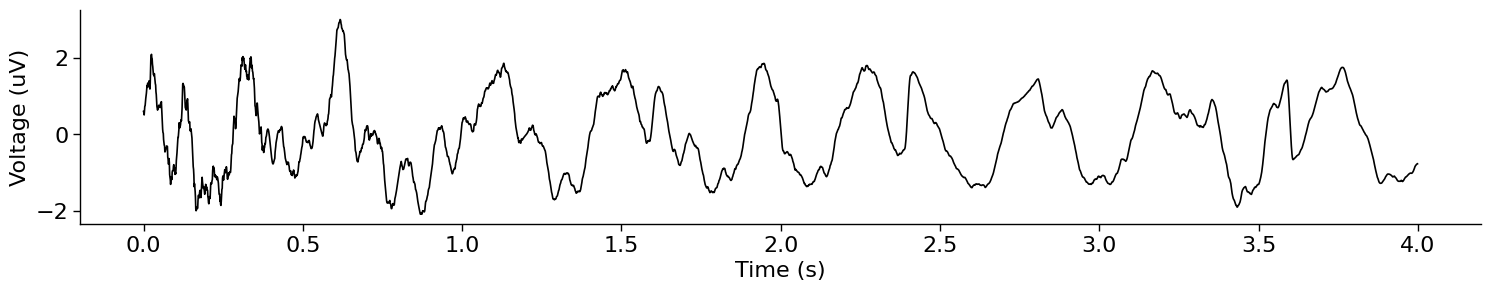

In [48]:
np.random.seed(10)
sig, times, true_amp, true_exp, osc1, osc2, aperiodic = sim_and_plot_bursty_oscillation()

In [49]:
len(times)*0.01

40.0

In [50]:
print(sig.shape)
print(times.shape)
print(true_amp.shape)
print(true_exp.shape)

(4000,)
(4000,)
(4000,)
(4000,)


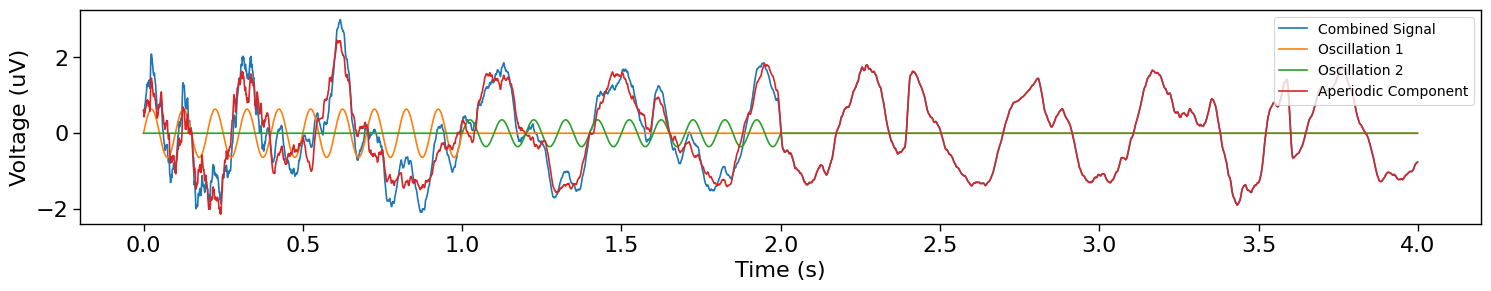

In [51]:
plot_time_series(times, [sig, osc1, osc2, aperiodic], labels=['Combined Signal', 'Oscillation 1', 'Oscillation 2', 'Aperiodic Component'], colors=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
plt.legend(loc='upper right', fontsize=10)

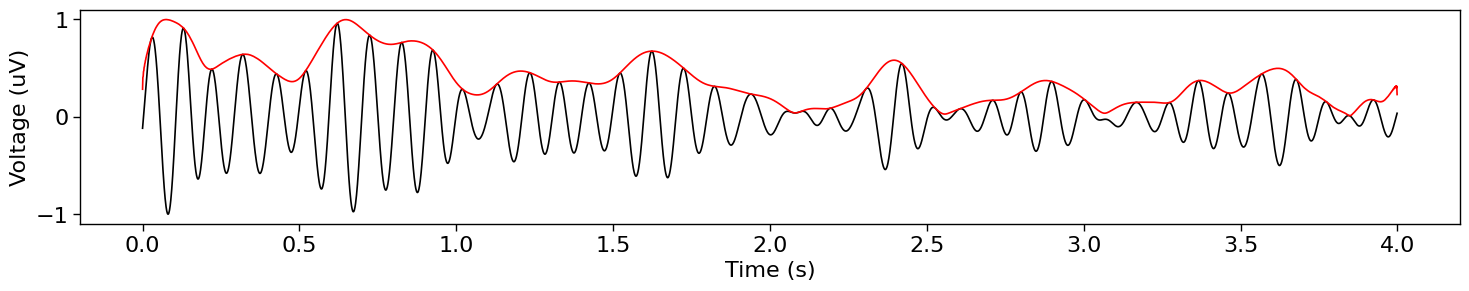

In [52]:
filt_sig = filter_signal(sig, FS, 'bandpass', f_range=(8, 12), remove_edges=False)
hilb = robust_hilbert(filt_sig)
inst_amp = amp_by_time(filt_sig, FS)
plot_time_series(times,[filt_sig, inst_amp])

C:\Users\dillc\AppData\Local\Temp\ipykernel_15864\1599843592.py:117: UserWarning: Legend does not support handles for Annotation instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  handles, labels = ax.get_legend_handles_labels()
C:\Users\dillc\AppData\Local\Temp\ipykernel_15864\1599843592.py:117: UserWarning: Legend does not support handles for Annotation instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  handles, labels = ax.get_legend_handles_labels()
C:\Users\dillc\AppData\Local\Temp\ipykernel_15864\1599843592.py:117: UserWarning: Legend does not support handles for Annotation instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  handles, labels = ax.get_legend_handles_labels()


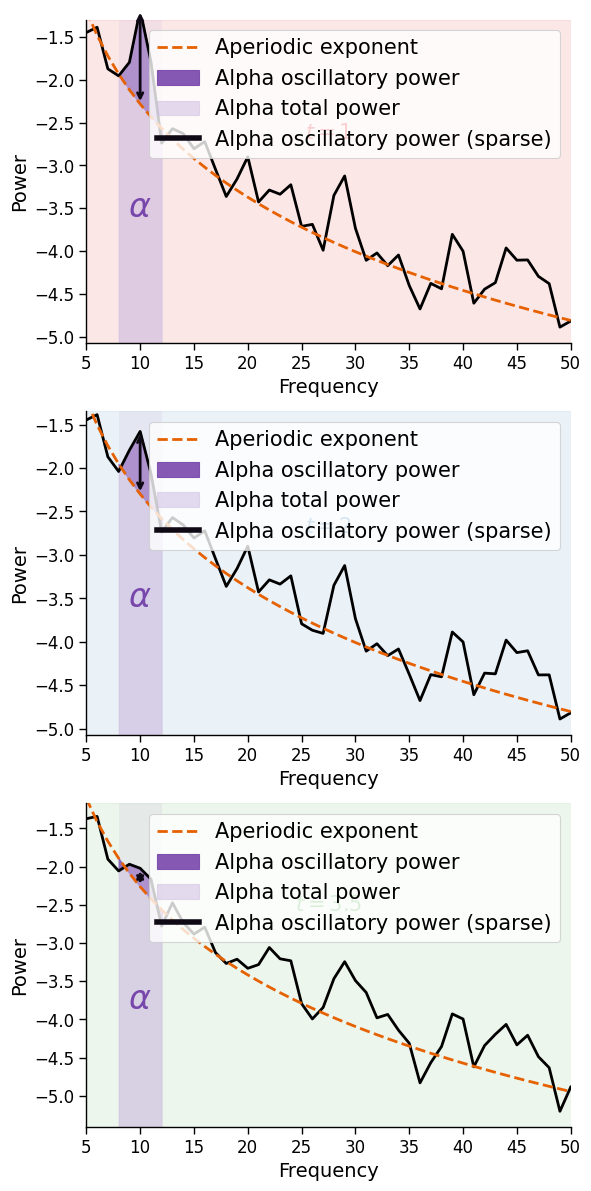

In [53]:
# Compute and plot TFR
fig, ax_tfr = plt.subplots(3, figsize=(6,12)) #fig.add_subplot(gs[0, 3:])
tps = [1, 2, 3.5]
colors = sns.color_palette("Set1", len(tps))
# freqs, _ = compute_spectrum(
#     sig, fs=FS, f_range=(1, 50), avg_type="median", nperseg=FS, noverlap=FS / 2
# )


# Plot spectral parameterization
axes_sp = []
for i, (tp, c) in enumerate(zip(tps, colors)):
    ax = ax_tfr[i]#fig.add_subplot(gs[1, 2 * i : 2 * (i + 1)])
    axes_sp.append(ax)
    plot_sparam_psd(sig, times, ax=ax, tp=tp, background_color=c, win_size=2)

C:\Users\dillc\AppData\Local\Temp\ipykernel_15864\4175144871.py:20: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax_osc_only.set_yticklabels(ax_osc_only.get_yticklabels(), fontsize=17)
C:\Users\dillc\AppData\Local\Temp\ipykernel_15864\4175144871.py:22: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax_osc_only.set_xticklabels(ax_osc_only.get_xticklabels(), fontsize=17)
C:\Users\dillc\AppData\Local\Temp\ipykernel_15864\4175144871.py:34: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax_aper_only.set_yticklabels(ax_aper_only.get_yticklabels(), fontsize=17)
C:\Users\dillc\AppData\Local\Temp\ipykernel_15864\4175144871.py:36: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax_aper_only.set_xticklabels(ax_aper_only.get_xticklabels(), fontsize=17)
C:\Users\dillc\AppData\Local\Temp\ipykernel_15864\4175144871.py:48: UserWarning: FixedFormatter should only be used together wit

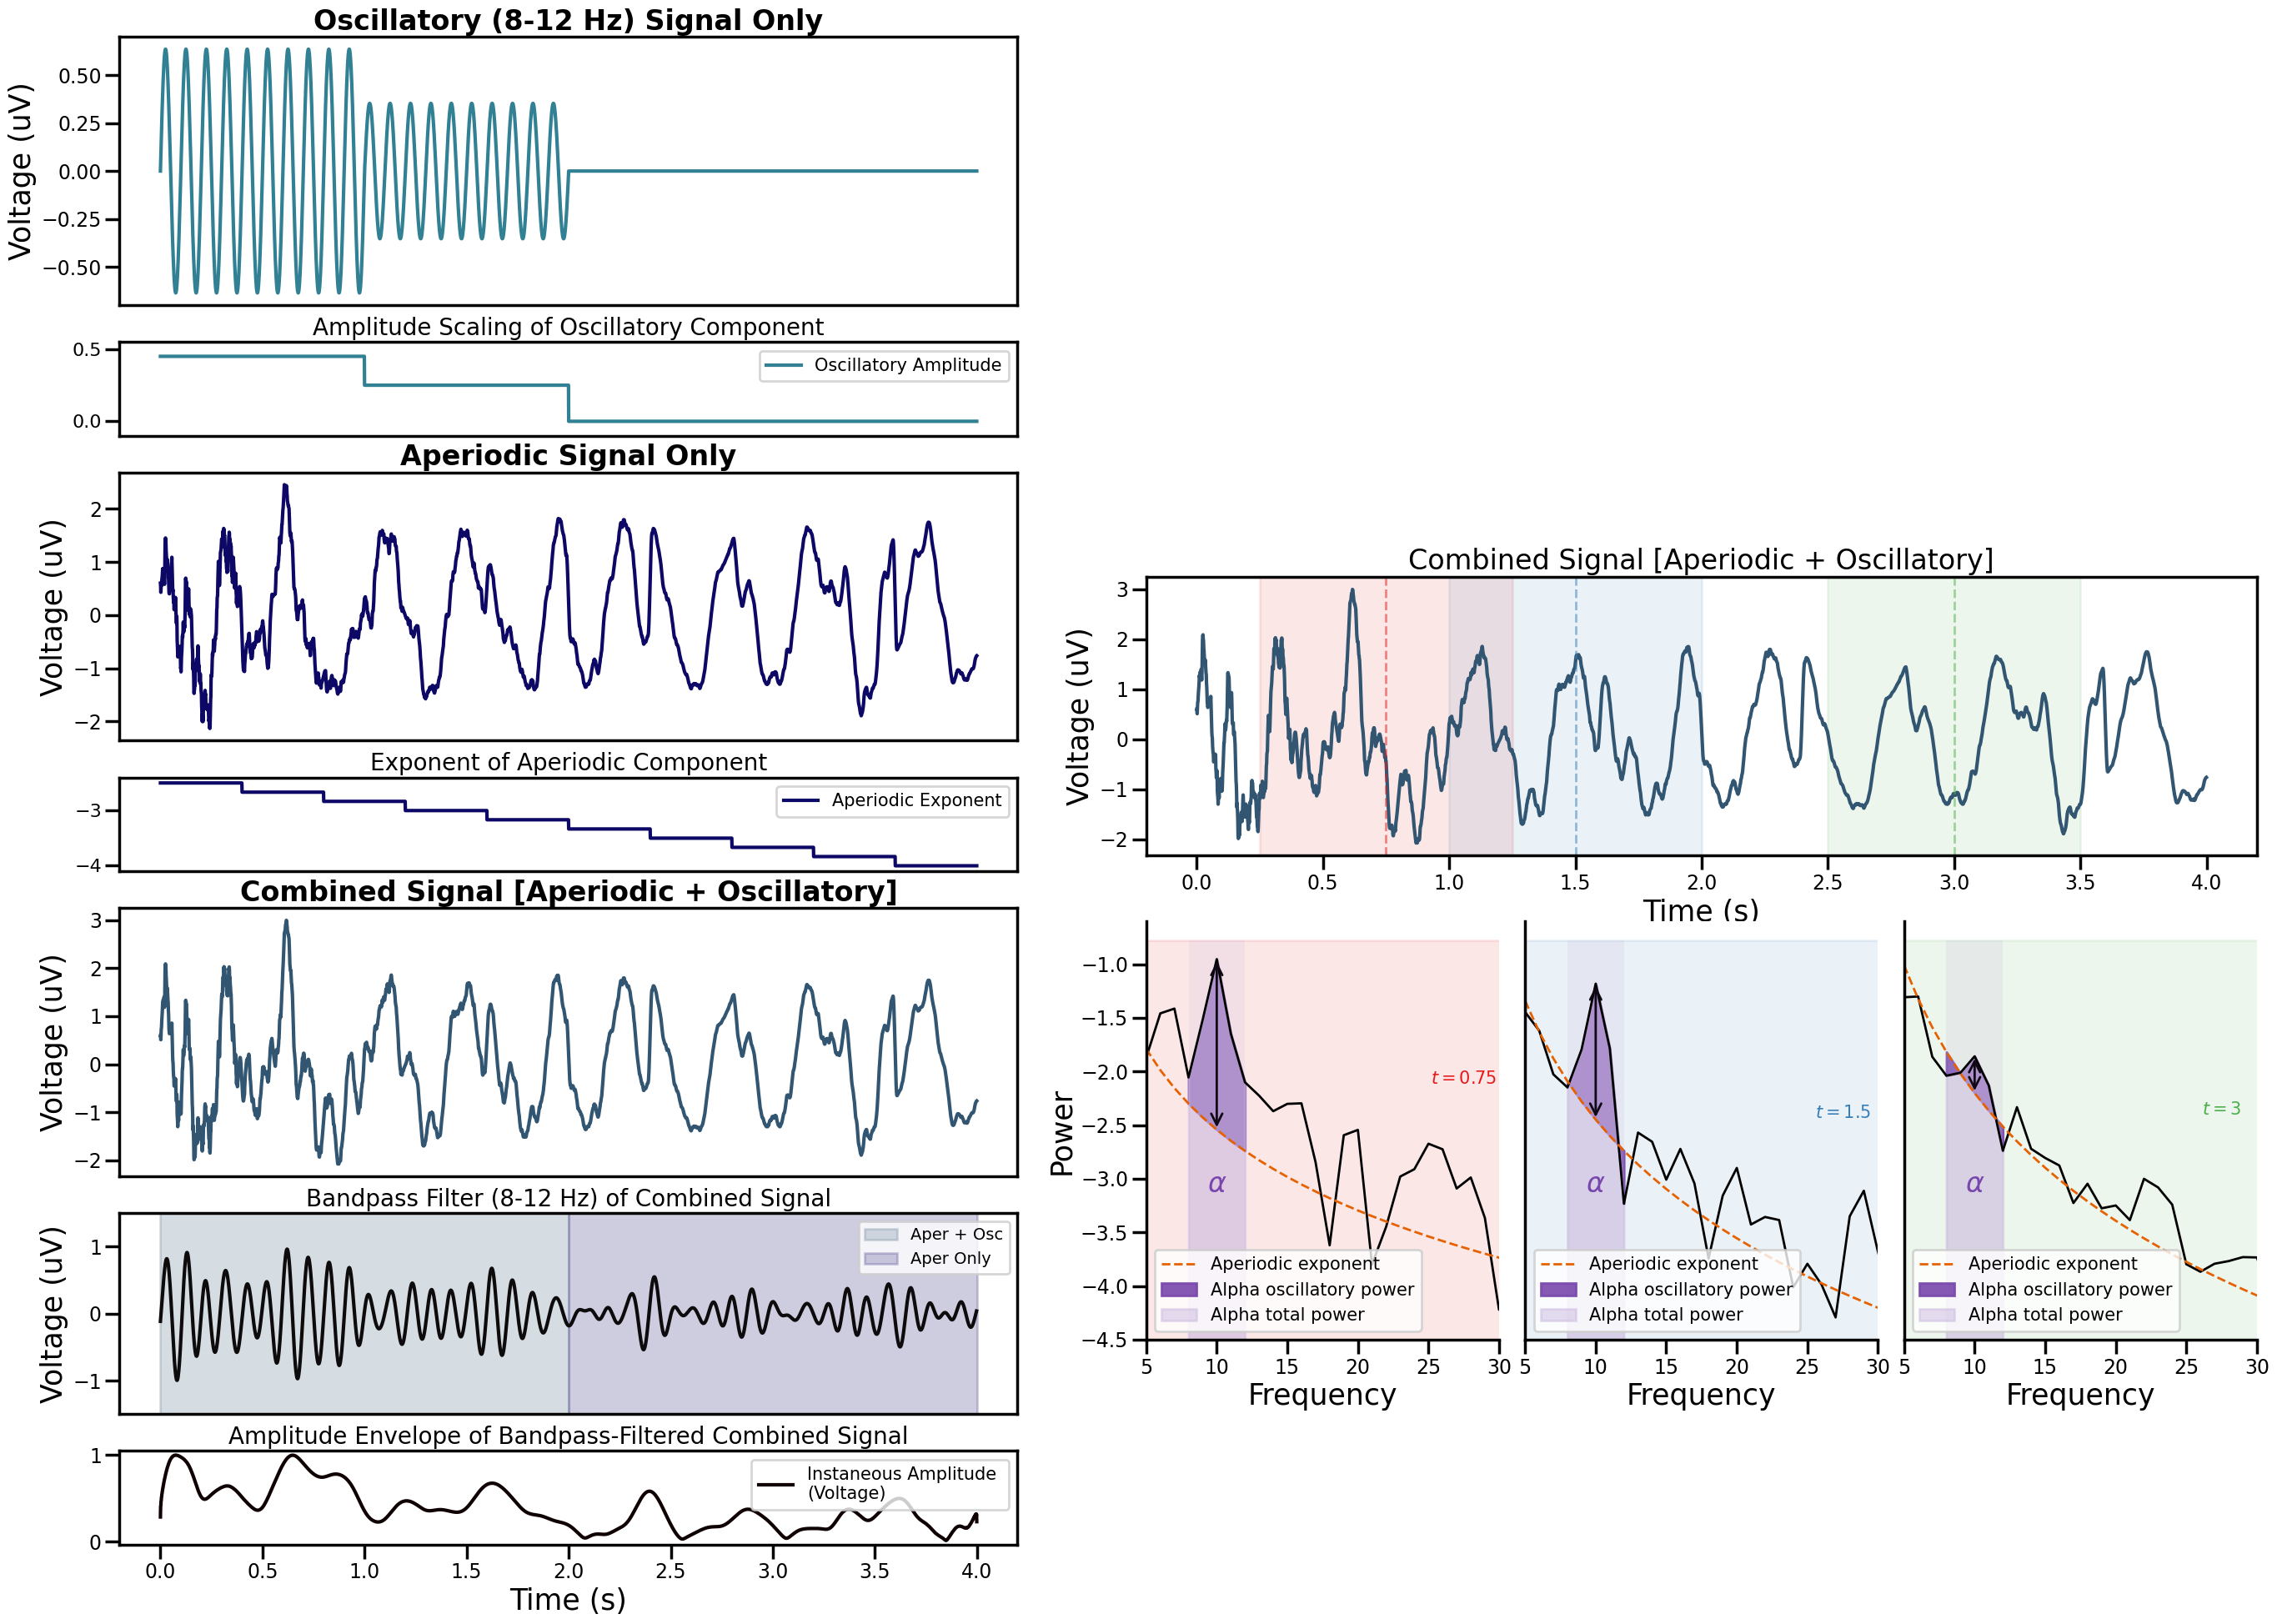

In [56]:
# create figure and gridspec
fig = plt.figure(figsize=(30,20), constrained_layout=False)
gs = gridspec.GridSpec(figure=fig, ncols=2, nrows=1, 
                        height_ratios=[1], width_ratios=[1,0.75])

aper_color = "#0d0865"
osc_color = "#318094"
combined_color = "#325672"

########################################
# Show osc component only
ax_osc = gridspec.GridSpecFromSubplotSpec(ncols=3, nrows=7, subplot_spec=gs[0], width_ratios=[2,5,2], height_ratios=[1,0.35,1,0.35,1,0.75,0.35])
ax_osc_only = fig.add_subplot(ax_osc[1])
plot_time_series(times, [osc1 + osc2], ax=ax_osc_only, labels=None,
                 colors=[osc_color])
# ax_osc_only.legend(loc='upper right', fontsize=10)
ax_osc_only.set_title('Oscillatory (8-12 Hz) Signal Only', weight='bold')
ax_osc_only.xaxis.set_visible(False)
ax_osc_only.set_ylabel(ax_osc_only.get_ylabel(), fontsize=25)
ax_osc_only.set_yticklabels(ax_osc_only.get_yticklabels(), fontsize=17)
ax_osc_only.set_xlabel(ax_osc_only.get_xlabel(), fontsize=25)
ax_osc_only.set_xticklabels(ax_osc_only.get_xticklabels(), fontsize=17)

########################################
# Show aperiodic componet only
# ax_aper = gridspec.GridSpecFromSubplotSpec(ncols=3, nrows=1, subplot_spec=gs[2], width_ratios=[2,5,2])
ax_aper_only = fig.add_subplot(ax_osc[7]) #4
plot_time_series(times, [aperiodic], ax=ax_aper_only, labels=None,
                 colors=[ aper_color])
# ax_aper_only.legend(loc='upper right', fontsize=10)
ax_aper_only.set_title('Aperiodic Signal Only', weight='bold')
ax_aper_only.xaxis.set_visible(False)
ax_aper_only.set_ylabel(ax_aper_only.get_ylabel(), fontsize=25)
ax_aper_only.set_yticklabels(ax_aper_only.get_yticklabels(), fontsize=17)
ax_aper_only.set_xlabel(ax_aper_only.get_xlabel(), fontsize=25)
ax_aper_only.set_xticklabels(ax_aper_only.get_xticklabels(), fontsize=17)

########################################
# Simulate and plot aperiodic + oscillation with events
# ax_all = gridspec.GridSpecFromSubplotSpec(ncols=3, nrows=1, subplot_spec=gs[4], width_ratios=[2,5,2])
ax_combined_sig = fig.add_subplot(ax_osc[13]) #7
plot_time_series(times, [sig], ax=ax_combined_sig,
                 labels='', 
                 colors=[ combined_color])
ax_combined_sig.set_title('Combined Signal [Aperiodic + Oscillatory]', weight='bold')
ax_combined_sig.xaxis.set_visible(False)
ax_combined_sig.set_ylabel(ax_combined_sig.get_ylabel(), fontsize=25)
ax_combined_sig.set_yticklabels(ax_combined_sig.get_yticklabels(), fontsize=17)
ax_combined_sig.set_xlabel(ax_combined_sig.get_xlabel(), fontsize=25)
ax_combined_sig.set_xticklabels(ax_combined_sig.get_xticklabels(), fontsize=17)

# ax_combined_sig.axvspan(xmin=0, xmax=1, alpha=0.2, color="#982ca0", label='APERIODIC + OSCILLATION')
# ax_combined_sig.axvspan(xmin=1, xmax=2, alpha=0.2, color='#d62728', label='ONLY APERIODIC')
# ax_combined_sig.legend(loc='lower right', fontsize=10)

########################################
# Show filtered sig and inst amplitude
# ax_filt = gridspec.GridSpecFromSubplotSpec(ncols=3, nrows=1, subplot_spec=gs[6], width_ratios=[2,5,2])
ax_filt_only = fig.add_subplot(ax_osc[16]) #10
plot_time_series(times, [filt_sig], ax=ax_filt_only, labels=None, #['Filtered Signal', "Amplitude Envelope"],
                 colors=[ "#0D0B0B"])
# ax_filt_only.legend(loc='lower left', fontsize=10)
ax_filt_only.set_title('Bandpass Filter (8-12 Hz) of Combined Signal', fontsize=20)
ax_filt_only.set_ylim(-1.5,1.5)
ax_filt_only.xaxis.set_visible(False)
ax_filt_only.axvspan(xmin=0, xmax=(N_SECONDS/2), alpha=0.2, color=combined_color, label='Aper + Osc')
ax_filt_only.axvspan(xmin=(N_SECONDS/2), xmax=N_SECONDS, alpha=0.2, color=aper_color, label='Aper Only')
ax_filt_only.legend(loc='upper right', fontsize=14)
ax_filt_only.set_ylabel(ax_filt_only.get_ylabel(), fontsize=25)
ax_filt_only.set_yticklabels(ax_filt_only.get_yticklabels(), fontsize=17)
ax_filt_only.set_xlabel(ax_filt_only.get_xlabel(), fontsize=25)
ax_filt_only.set_xticklabels(ax_filt_only.get_xticklabels(), fontsize=17)

########################################
# Plot osc amplitude and exp across time
# ax_amp_exp = gridspec.GridSpecFromSubplotSpec(ncols=3, nrows=3, subplot_spec=gs[1], width_ratios=[2,5,2], height_ratios=[1,1, 1])

ax_amp = fig.add_subplot(ax_osc[4]) #13
plot_time_series(times, [true_amp], ax=ax_amp, labels=['Oscillatory Amplitude'],
                 colors=[ osc_color])
ax_amp.legend(loc='upper right', fontsize=15)
ax_amp.xaxis.set_visible(False)
ax_amp.set_ylabel('')
ax_amp.set_title('Amplitude Scaling of Oscillatory Component', fontsize=20)
ax_amp.set_ylim(-0.1,AMP1+0.1)

ax_exp = fig.add_subplot(ax_osc[10]) #16
plot_time_series(times, [true_exp], ax=ax_exp, labels=['Aperiodic Exponent'],
                 colors=[ aper_color])
ax_exp.legend(loc='upper right', fontsize=15)
ax_exp.set_ylabel('')
ax_exp.set_title('Exponent of Aperiodic Component', fontsize=20)
ax_exp.set_ylim(EXP2-0.1,EXP1+0.1)
ax_exp.xaxis.set_visible(False)

ax_inst = fig.add_subplot(ax_osc[19]) #19
plot_time_series(times, [inst_amp], ax=ax_inst, labels=['Instaneous Amplitude \n(Voltage)'],
                 colors=[ "#0f0101"])
ax_inst.legend(loc='upper right', fontsize=15)
ax_inst.set_ylabel('')
ax_inst.set_title('Amplitude Envelope of Bandpass-Filtered Combined Signal', fontsize=20)
ax_inst.set_ylabel(ax_inst.get_ylabel(), fontsize=25)
ax_inst.set_yticklabels(ax_inst.get_yticklabels(), fontsize=17)
ax_inst.set_xlabel(ax_inst.get_xlabel(), fontsize=25)
ax_inst.set_xticklabels(ax_inst.get_xticklabels(), fontsize=17)
# ax_inst.set_ylim(-0.2,1.2)
ax_inst.xaxis.set_visible(True)


########################################
# Plot osc amplitude and exp across time
ax_timeseries = gridspec.GridSpecFromSubplotSpec(ncols=5, nrows=4, subplot_spec=gs[1], width_ratios=[1,0.25,1,0.25,1], height_ratios=[0.85,0.5,0.75,0.25])
ax_combined_sig = fig.add_subplot(ax_timeseries[5:10])

tps = [0.75, 1.5, 3]
win_size=1
colors = sns.color_palette("Set1", len(tps))

plot_time_series(times, [sig], ax=ax_combined_sig,
                 labels='', 
                 colors=[ combined_color])
for tp_idx in range(len(tps)):
    ax_combined_sig.axvspan(xmin=(tps[tp_idx]-(win_size/2)), xmax=(tps[tp_idx]+(win_size/2)), color=colors[tp_idx], alpha=0.1)
    ax_combined_sig.axvline(tps[tp_idx], linewidth=2, color=colors[tp_idx], alpha=0.5, linestyle='--')
ax_combined_sig.set_title('Combined Signal [Aperiodic + Oscillatory]')
ax_combined_sig.xaxis.set_visible(True)
ax_combined_sig.set_ylabel(ax_combined_sig.get_ylabel(), fontsize=25)
ax_combined_sig.set_yticklabels(ax_combined_sig.get_yticklabels(), fontsize=17)
ax_combined_sig.set_xlabel(ax_combined_sig.get_xlabel(), fontsize=25)
ax_combined_sig.set_xticklabels(ax_combined_sig.get_xticklabels(), fontsize=17)



# ########################################
# Plot osc amplitude and exp across time
# ax_psd = gridspec.GridSpecFromSubplotSpec(ncols=1, nrows=3, subplot_spec=gs[3], width_ratios=[1], height_ratios=[1])
ax_psd1 = fig.add_subplot(ax_timeseries[10])
ax_psd2 = fig.add_subplot(ax_timeseries[12])
ax_psd3 = fig.add_subplot(ax_timeseries[14])

# Plot spectral parameterization
axes_sp = [ax_psd1,ax_psd2,ax_psd3]
for i, (tp, c) in enumerate(zip(tps, colors)):
    ax = axes_sp[i]#fig.add_subplot(gs[1, 2 * i : 2 * (i + 1)])
    # axes_sp.append(ax)
    ymin, ymax = -4.5,-0.6
    plot_sparam_psd(sig, times, ax=ax, tp=tp, background_color=c, win_size=win_size, ylims=(ymin, ymax))
    ax.set_ylim(ymin, ymax)
    ax.set_xlim(5,30)
    ax.legend(fontsize=15, loc='lower left')
    ax.set_ylabel(ax.get_ylabel(), fontsize=25)
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=17)
    ax.set_xlabel(ax.get_xlabel(), fontsize=25)
    ax.set_xticklabels(ax.get_xticklabels(), fontsize=17)
    if i > 0:
        ax.yaxis.set_visible(False)

plt.tight_layout()
fig.tight_layout()
SAVE_FIG = True
if SAVE_FIG:
    plt.savefig(
        f"{FIG_DIR}/Intro_AlphaBurst_Aper.png", dpi=300
    )


---

## Figure 4 in paper (Recommendation 3)

### Generate PSD with & without Knee

c:\Users\dillc\anaconda3\envs\aperiodicMethods\Lib\site-packages\neurodsp\sim\transients.py:67: UserWarning: Rise time constant should be shorter than decay time constant.
  warn('Rise time constant should be shorter than decay time constant.')
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


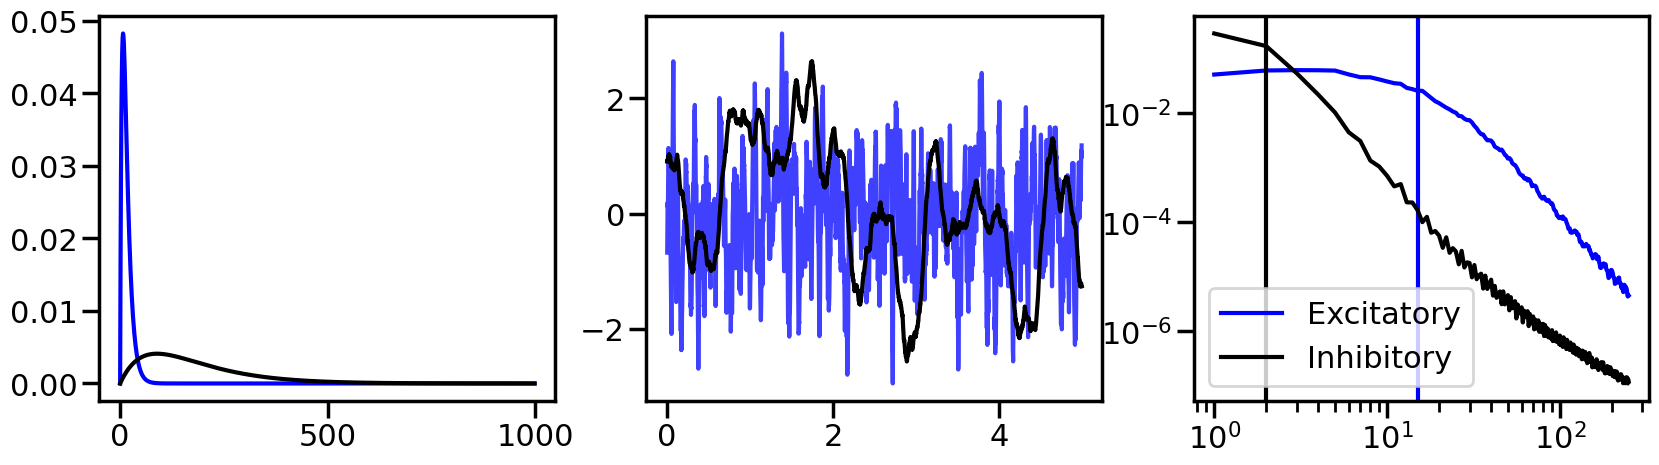

In [6]:
highKnee = 15
lowKnee = 2

tau_E = (0.005, (1 / (2 * np.pi * highKnee)))  # rise, decay
tau_I = (0.1, (1 / (2 * np.pi * lowKnee)))  # rise, decay
n_E = 8000
n_I = 2000
firRate_E = 2  # Hz
firRate_I = 2  # Hz
scale_I = 1
n_seconds = 200
fs = 1000
f_range = (1, 250)


fig, ax = plt.subplots(1, 3, figsize=(20, 5))

## Simulate synaptic kernels with slower and faster rise/decay rates
sig_E_ker = sim_synaptic_kernel(
    n_seconds=1, fs=fs, tau_r=tau_E[0], tau_d=tau_E[1]
)
sig_I_ker = sim_synaptic_kernel(
    n_seconds=1, fs=fs, tau_r=tau_I[0], tau_d=tau_I[1]
)

ax[0].plot(sig_E_ker, label="Excitatory", color="b")
ax[0].plot(sig_I_ker, label="Inhibitory", color="k")
plt.legend()

## Use these to simulate currents from both of these; this will give us a slower (inhibitory) signal, and a faster (excitatory) one
sig_E = sim_synaptic_current(
    n_seconds=n_seconds,
    fs=fs,
    n_neurons=n_E,
    firing_rate=firRate_E,
    tau_r=tau_E[0],
    tau_d=tau_E[1],
)
sig_I = (
    sim_synaptic_current(
        n_seconds=n_seconds,
        fs=fs,
        n_neurons=n_I,
        firing_rate=firRate_I,
        tau_r=tau_I[0],
        tau_d=tau_I[1],
    )
    * scale_I
)
time = np.arange(0, len(sig_E)) / fs
# only plotting the first 5 seconds for ease of vis
ax[1].plot(time[time < 5], sig_E[time < 5], label="E", alpha=0.75, color="b")
ax[1].plot(time[time < 5], sig_I[time < 5], label="I", color="k")

## Calc PSDs for each timeseries and plot; these should have different knees
freqs_fast, powers_fast = compute_spectrum(
    sig_E, fs, f_range=f_range, avg_type="mean", nperseg=fs, noverlap=fs / 2
)
freqs_slow, powers_slow = compute_spectrum(
    sig_I, fs, f_range=f_range, avg_type="mean", nperseg=fs, noverlap=fs / 2
)

ax[2].loglog(freqs_fast, powers_fast, label="Excitatory", color="b")
ax[2].axvline(highKnee, color="b")
ax[2].loglog(freqs_slow, powers_slow, label="Inhibitory", color="k")
ax[2].axvline(lowKnee, color="k")

plt.legend()

### Show knees with different plots (log-log, semilog, linear) and FOOOF fit

In [39]:
FIG_DIR ='C:\\Users\\dillc\\OneDrive\\UCSD\\Voytek_Lab\\code_dev\\AperiodicMethods\\notebooks\\images\\Rec03_Knees'

C:\Users\dillc\AppData\Local\Temp\ipykernel_15864\2444860067.py:69: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax_i.set_xticklabels(ax_i.get_xticklabels(), fontsize=labels_size-2)
C:\Users\dillc\AppData\Local\Temp\ipykernel_15864\2444860067.py:70: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax_i.set_yticklabels(ax_i.get_yticklabels(), fontsize=labels_size-4)


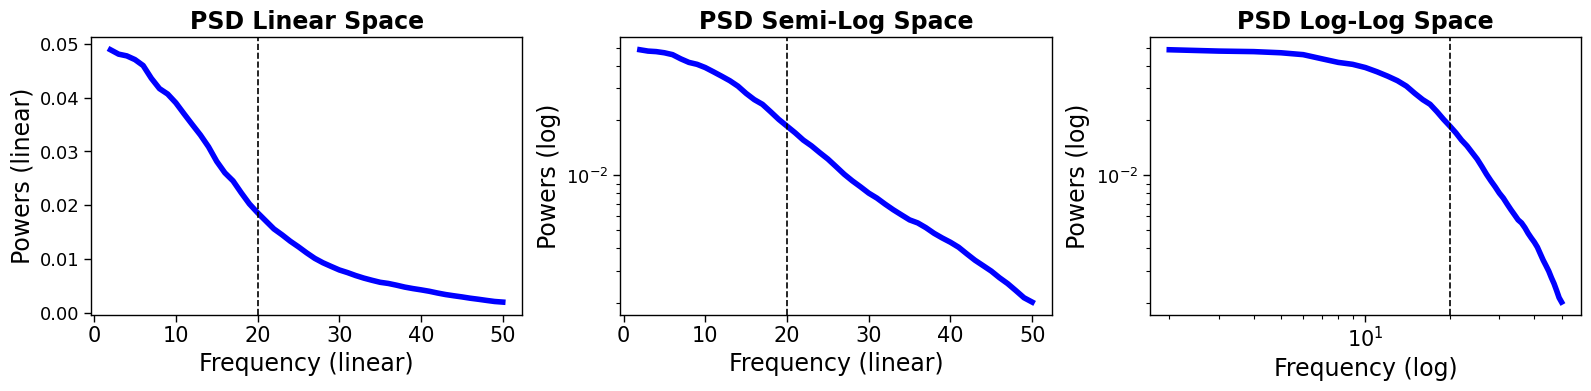

In [44]:
sns.set_context("paper")
highKnee = 20
tau_E = (0.005, (1 / (2 * np.pi * highKnee)))  # rise, decay
n_E = 10000
firRate_E = 10  # Hz
n_seconds = 5000
fs = 1000
f_range = (2, 50)


fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(16, 4))
labels_size = 17
linewidth = 4

## Use these to simulate currents from both of these; this will give us a slower (inhibitory) signal, and a faster (excitatory) one
sig_E = sim_synaptic_current(
    n_seconds=n_seconds,
    fs=fs,
    n_neurons=n_E,
    firing_rate=firRate_E,
    tau_r=tau_E[0],
    tau_d=tau_E[1],
)

## Calc PSDs for each timeseries and plot; these should have different knees
freqs_fast, powers_fast = compute_spectrum(
    sig_E, fs, f_range=f_range, avg_type="mean", nperseg=fs, noverlap=fs / 2
)

ax[0].set_title("PSD Linear Space", fontsize=labels_size, fontweight='bold')
ax[0].plot(
    freqs_fast,
    powers_fast,
    label=f"Knee Freq: {highKnee}",
    color="b",
    linewidth=linewidth,
)
ax[0].set_xlabel("Frequency (linear)", fontsize=labels_size)
ax[0].set_ylabel("Powers (linear)", fontsize=labels_size)
# plt.show()

ax[1].set_title("PSD Semi-Log Space", fontsize=labels_size, fontweight='bold')
ax[1].semilogy(
    freqs_fast,
    powers_fast,
    label=f"Knee Freq: {highKnee}",
    color="b",
    linewidth=linewidth,
)
ax[1].set_xlabel("Frequency (linear)", fontsize=labels_size)
ax[1].set_ylabel("Powers (log)", fontsize=labels_size)
# ax[1].axvline(highKnee, color='k', linestyle='--')

ax[2].set_title("PSD Log-Log Space", fontsize=labels_size, fontweight='bold')
ax[2].loglog(
    freqs_fast,
    powers_fast,
    label=f"Knee Freq: {highKnee}",
    color="b",
    linewidth=linewidth,
)
ax[2].set_xlabel("Frequency (log)", fontsize=labels_size)
ax[2].set_ylabel("Powers (log)", fontsize=labels_size)
# ax[2].axvline(highKnee, color='k', linestyle='--')
# plt.legend()

for ax_i in ax:
    ax_i.axvline(highKnee, color='k', linestyle='--')
    ax_i.set_xticklabels(ax_i.get_xticklabels(), fontsize=labels_size-2)
    ax_i.set_yticklabels(ax_i.get_yticklabels(), fontsize=labels_size-4)
# plt.legend()

plt.tight_layout()
plt.savefig(FIG_DIR+"\\knees1.png", dpi=300)

C:\Users\dillc\AppData\Local\Temp\ipykernel_15864\1472790418.py:38: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax_i.set_xticklabels(ax_i.get_xticklabels(), fontsize=labels_size-2)
C:\Users\dillc\AppData\Local\Temp\ipykernel_15864\1472790418.py:39: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax_i.set_yticklabels(ax_i.get_yticklabels(), fontsize=labels_size-4)


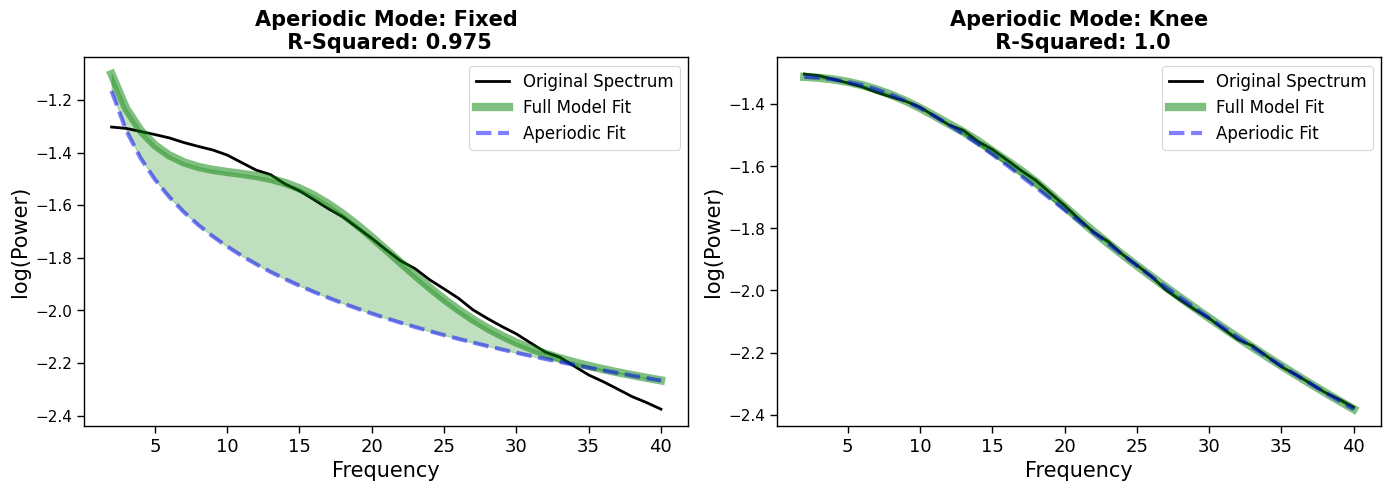

In [42]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(14, 5))
labels_size = 15

fit_settings = {"freq_range": (1, 40)}
init_settings = {
    "peak_width_limits": (2, 14),
    "peak_threshold": 2,
    "max_n_peaks": 4,
}

init_settings["aperiodic_mode"] = "fixed"
fm_f = fooof.FOOOF(**init_settings)
fm_f.fit(freqs=freqs_fast, power_spectrum=powers_fast, **fit_settings)
# exp = np.round(fm.get_results().aperiodic_params[1], decimals=3)
# frange = ax_dict[i]['freq_range']
fm_f.plot(ax=ax[0], model_kwargs={'color':'g', 'linewidth':6}, plot_peaks='shade')
ax[0].set_title(
    f"Aperiodic Mode: Fixed\n R-Squared: {np.round(fm_f.r_squared_, decimals=3)}",
    fontsize=labels_size, fontweight='bold'
)

init_settings["aperiodic_mode"] = "knee"
fm_k = fooof.FOOOF(**init_settings)
fm_k.fit(freqs=freqs_fast, power_spectrum=powers_fast, **fit_settings)
# exp = np.round(fm.get_results().aperiodic_params[1], decimals=3)
# frange = ax_dict[i]['freq_range']
fm_k.plot(ax=ax[1], model_kwargs={'color':'g', 'linewidth':6}, plot_peaks='shade')
ax[1].set_title(
    f"Aperiodic Mode: Knee\n R-Squared: {np.round(fm_k.r_squared_, decimals=3)}",
    fontsize=labels_size, fontweight='bold'
)


for ax_i in ax:
    # ax_i.axvline(highKnee, color='k', linestyle='--')
    ax_i.set_xlabel(ax_i.get_xlabel(), fontsize=labels_size)
    ax_i.set_ylabel(ax_i.get_ylabel(), fontsize=labels_size)
    ax_i.set_xticklabels(ax_i.get_xticklabels(), fontsize=labels_size-2)
    ax_i.set_yticklabels(ax_i.get_yticklabels(), fontsize=labels_size-4)

    ax_i.grid(False)


plt.tight_layout()
plt.savefig(FIG_DIR+"\\knees2.png", dpi=300)

__________

## Figure 6 Gyurkovics figure (Recommendation 4)
We're only exporting figures to be put into an adobe illustrator file afterwards, for this figure

In [18]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from neurodsp.sim import sim_knee
from neurodsp.sim.transients import sim_damped_erp
from neurodsp.sim.utils import rotate_timeseries
from neurodsp.spectral import compute_spectrum
from neurodsp.utils import create_times

In [19]:
n_trials = 5

## Simulate timeseries as a combination of aperiodic and periodic components
sim_components = {"sim_knee": {"exponent1": 0, "exponent2": -2, "knee": 10}}
fs = 1000
n_seconds = 2

pre_stim_aper = {"time": [], "freqs": [], "pows": []}
post_stim_combined = {"time": [], "freqs": [], "pows": []}
for t in range(n_trials):

    ap_shift = (
        np.random.random()
    )  # randomize the degree of aperiodic change pre-to-post stim
    erp_amp = np.random.randint(low=1, high=5)  # randomize ERP amplitude
    erp_latency = 0.25 + (
        np.random.randint(-100, 100) / 1000
    )  # 0.25 # jitter ERP start time
    # print(ap_shift, erp_amp, erp_latency)

    ## generate signals
    ap_sig_pre = sim_knee(n_seconds, fs, **sim_components["sim_knee"])
    ap_sig_post = rotate_timeseries(
        ap_sig_pre, fs, delta_exp=ap_shift, f_rotation=15
    )
    erp_sig = sim_damped_erp(
        n_seconds, fs, amp=erp_amp, freq=5, decay=0.05, time_start=erp_latency
    )
    erp_plus_aper = ap_sig_post + erp_sig

    ## add the timeseries to our dictionary
    pre_stim_aper["time"].append(ap_sig_pre)
    post_stim_combined["time"].append(erp_plus_aper)

    ## Compute the power spectrum using Welch's
    freqs_pre, powers_pre = compute_spectrum(
        ap_sig_pre,
        fs=fs,
        f_range=(0.1, 30),
        avg_type="median",
        nperseg=fs,
        noverlap=fs / 2,
    )
    freqs_erp_plus, powers_erp_plus = compute_spectrum(
        erp_plus_aper,
        fs=fs,
        f_range=(0.1, 30),
        avg_type="median",
        nperseg=fs,
        noverlap=fs / 2,
    )

    ## add the PSDs to the dictionary
    pre_stim_aper["freqs"].append(freqs_pre)
    post_stim_combined["freqs"].append(freqs_erp_plus)
    pre_stim_aper["pows"].append(powers_pre)
    post_stim_combined["pows"].append(powers_erp_plus)

## get the pre-stim window and post stim time windows, without averaging
pre_stim_sigs = np.vstack(pre_stim_aper["time"])
post_stim_sigs = np.vstack(post_stim_combined["time"])
## get pre-stim and post stim PSDs, with averaging
pre_stim_freqs = np.mean(np.vstack(pre_stim_aper["freqs"]), axis=0)
post_stim_freqs = np.mean(np.vstack(post_stim_combined["freqs"]), axis=0)
pre_stim_pows = np.mean(np.vstack(pre_stim_aper["pows"]), axis=0)
post_stim_pows = np.mean(np.vstack(post_stim_combined["pows"]), axis=0)

# do baseline correction of post-stimulus time signals, and then average these to get ERP
baseline_corr_erp = np.mean((post_stim_sigs - pre_stim_sigs), axis=0)
# calculate PSD of ERP
freqs_erp, powers_erp = compute_spectrum(
    baseline_corr_erp,
    fs=fs,
    f_range=(0.1, 50),
    avg_type="median",
    nperseg=fs,
    noverlap=fs / 2,
)

# plot timeseries
times = create_times(n_seconds=n_seconds, fs=fs)

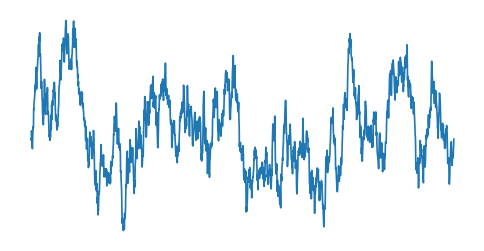

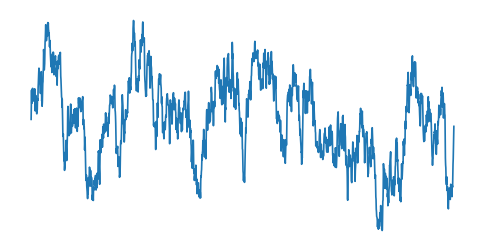

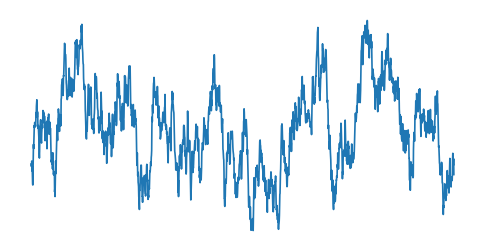

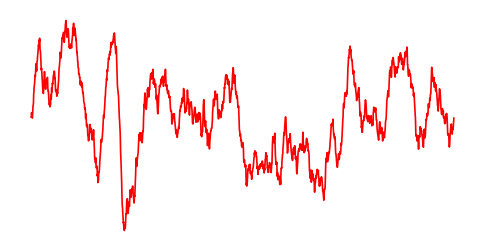

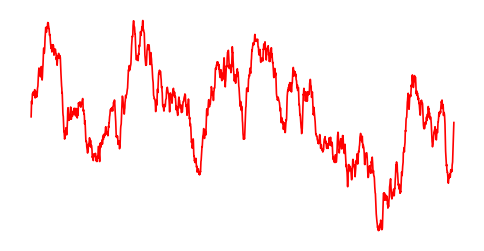

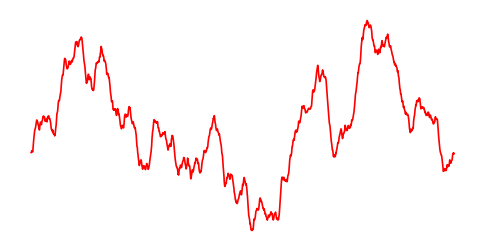

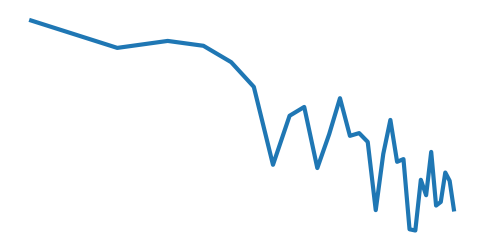

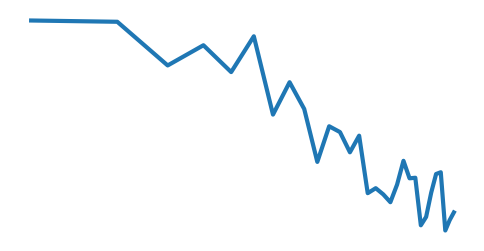

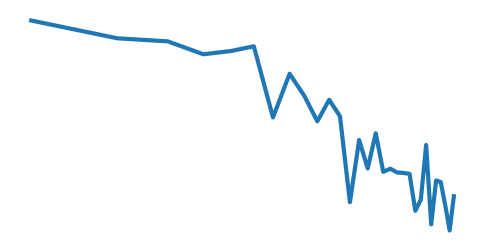

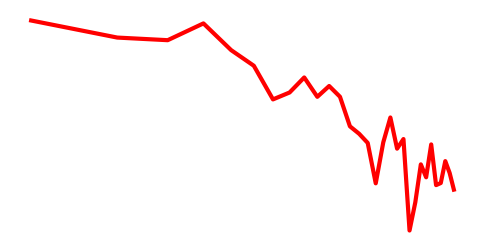

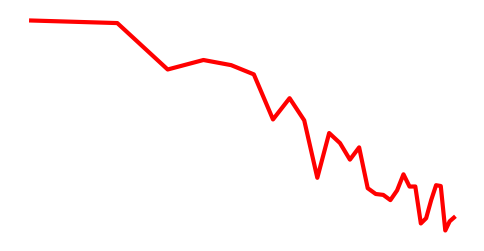

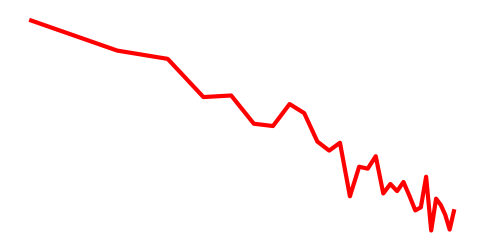

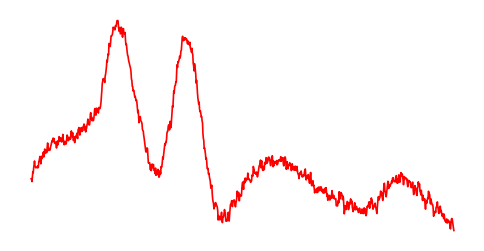

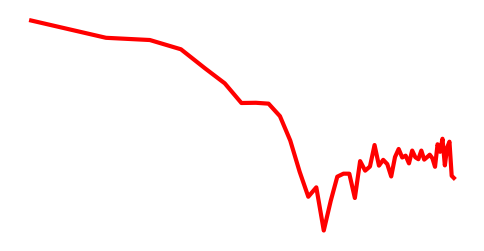

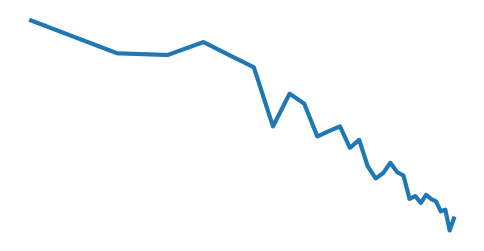

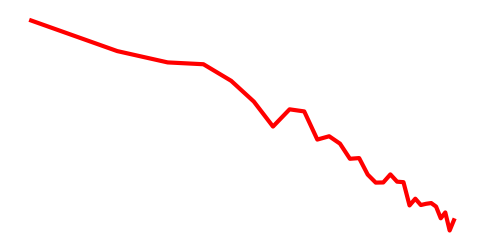

In [20]:
for t in range(3):
    fig, ax = plt.subplots(figsize=(6, 3))
    plt.plot(times, pre_stim_aper["time"][t])
    plt.axis("off")
    if SAVE_FIG:
        fig.savefig(f"./images/pre_stim_time_domain_{t}.png")
for t in range(3):
    fig, ax = plt.subplots(figsize=(6, 3))
    plt.plot(times, post_stim_combined["time"][t], color="r")
    plt.axis("off")
    if SAVE_FIG:
        fig.savefig(f"./images/post_stim_time_domain_{t}.png")
for t in range(3):
    fig, ax = plt.subplots(figsize=(6, 3))
    plt.loglog(
        pre_stim_aper["freqs"][t], pre_stim_aper["pows"][t], linewidth=3
    )
    plt.axis("off")
    if SAVE_FIG:
        fig.savefig(f"./images/pre_stim_spec_domain_{t}.png")
for t in range(3):
    fig, ax = plt.subplots(figsize=(6, 3))
    plt.loglog(
        post_stim_combined["freqs"][t],
        post_stim_combined["pows"][t],
        color="r",
        linewidth=3,
    )
    plt.axis("off")
    if SAVE_FIG:
        fig.savefig(f"./images/post_stim_spec_domain_{t}.png")

fig, ax = plt.subplots(figsize=(6, 3))
plt.plot(times[times < 1], baseline_corr_erp[times < 1], color="r")
plt.axis("off")
if SAVE_FIG:
    fig.savefig(f"./images/erp_time_domain.png")

fig, ax = plt.subplots(figsize=(6, 3))
plt.loglog(freqs_erp, powers_erp, color="r", linewidth=3)
plt.axis("off")
if SAVE_FIG:
    fig.savefig(f"./images/erp_spec_domain.png")

fig, ax = plt.subplots(figsize=(6, 3))
plt.loglog(pre_stim_freqs, pre_stim_pows, linewidth=3)
plt.axis("off")
if SAVE_FIG:
    fig.savefig(f"./images/pre_spec_domain.png")

fig, ax = plt.subplots(figsize=(6, 3))
plt.loglog(post_stim_freqs, post_stim_pows, color="r", linewidth=3)
plt.axis("off")
if SAVE_FIG:
    fig.savefig(f"./images/post_spec_domain.png")

In [21]:
from neurodsp.sim import sim_variable_oscillation

n_trials = 10 

## Simulate timeseries as a combination of aperiodic and periodic components
sim_components = {"sim_knee": {"exponent1": 0, "exponent2": -2, "knee": 10}}

fs = 1000
n_seconds = 20
times = create_times(n_seconds=n_seconds, fs=fs)

phase = 0
var_oscs = np.zeros(shape=(n_trials, len(times)))
ap_sigs = np.zeros(shape=(n_trials, len(times)))
osc_only = np.zeros(shape=(n_trials, len(times)))
for t in range(n_trials):

    phase = phase + 0.1
    var_osc = sim_variable_oscillation(
        n_seconds,
        fs,
        freqs=np.tile([10, 9.5, 10.5, 10, 9.5, 9], 20),
        cycle="sine",
        phase=phase,
    )
    ap_sig = sim_knee(n_seconds, fs, **sim_components["sim_knee"])
    ap_sigs[t, :] = ap_sig

    ap_shift = (
        np.random.random()
    )  # randomize the degree of aperiodic change pre-to-post stim
    print(ap_shift)
    ap_sig_post = rotate_timeseries(
        ap_sig, fs, delta_exp=ap_shift, f_rotation=15
    )
    n_replace_timepoints = int(len(times) / 2)
    replace_idx = np.random.randint(low=1, high=n_replace_timepoints)

    # plot_time_series(times=times, sigs = var_osc)
    # ap_sig[replace_idx:(replace_idx+n_replace_timepoints)] = ap_sig_post[replace_idx:(replace_idx+n_replace_timepoints)]
    var_oscs[t, :] = var_osc + (ap_sig_post * 0.5)
    osc_only[t, :] = var_osc

# get the spectrum of each trial
freqs, spec = compute_spectrum(sig=var_oscs, fs=fs)
# average the spectra
freqs_freq_avg, spec_freq_avg = freqs, spec.mean(axis=0)
# average in the time domain across trials, and then compute spectra
freqs_time_avg, spec_time_avg = compute_spectrum(
    sig=var_oscs.mean(axis=0), fs=fs
)
# get power spectra of ap_sig (eg, pre-stimulus signal)
freqs_pre, spec_pre = compute_spectrum(sig=ap_sigs.mean(axis=0), fs=fs)

0.892550248365642
0.1725796220824406
0.13205272773701793
0.9983243696807241
0.5321238869509942
0.04423354752712727
0.3753757475179693
0.378457984321631
0.01983261657087032
0.6838821989545808


-----

## Figure 5 (Recommendation 3)

0.014453612588581102 -0.0002502940899692159 0.10115601475897436


C:\Users\dillc\AppData\Local\Temp\ipykernel_2148\4123116345.py:36: MatplotlibDeprecationWarning: Auto-removal of overlapping axes is deprecated since 3.6 and will be removed two minor releases later; explicitly call ax.remove() as needed.
  ax = plt.subplot(gs0)
C:\Users\dillc\AppData\Local\Temp\ipykernel_2148\4123116345.py:65: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(ax.get_xticklabels(), rotation=50, fontsize=12)


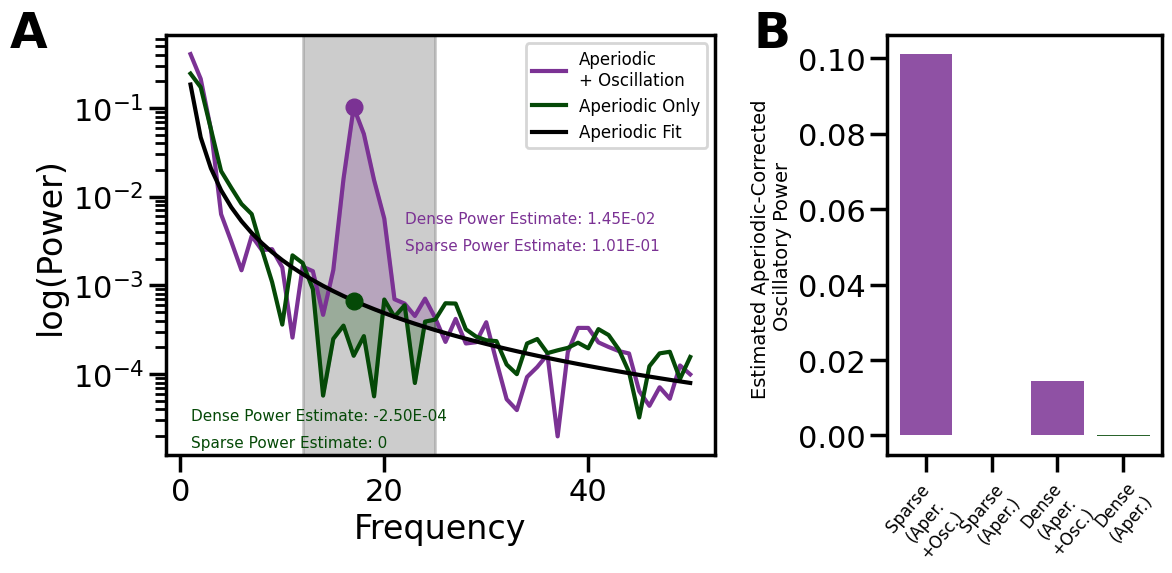

In [13]:
## Simulate timeseries as a combination of aperiodic and periodic components
sim_components = {"sim_knee": {"exponent1": 0, "exponent2": -2, "knee": 0}}
fs = 1000
n_seconds = 2
np.random.seed(36)
ap_sig = sim_knee(n_seconds, fs, **sim_components["sim_knee"])
sig = sim_peak_oscillation(ap_sig, fs, freq=18, bw=1.75, height=2.5)

## Compute the power spectrum using Welch's
freqs, powers = compute_spectrum(
    sig, fs=fs, f_range=(1, 50), avg_type="median", nperseg=fs, noverlap=fs / 2
)
## Compute the power spectrum using Welch's
freqs, powers_ap = compute_spectrum(
    ap_sig, fs=fs, f_range=(1, 50), avg_type="median", nperseg=fs, noverlap=fs / 2
)

fm = fooof.FOOOF(peak_width_limits=(2,12), peak_threshold=3)
fm.fit(freqs, powers_ap)
# offset, exp = fm.aperiodic_params_
# ys = offset + (freqs*exp)
ys = 10**(fm._ap_fit)

freqs_mask = (freqs > 12) & (freqs <= 25)
red_diff = np.mean(powers[freqs_mask] - ys[freqs_mask])
blue_diff = np.mean(powers_ap[freqs_mask] - ys[freqs_mask])
pk_peak = powers[freqs_mask][np.argmax(powers[freqs_mask])] 
pk_hght = powers[freqs_mask][np.argmax(powers[freqs_mask])] - ys[freqs_mask][np.argmax(powers[freqs_mask])]
pk_ctr = freqs[freqs_mask][np.argmax(powers[freqs_mask])] 
blue_hght = ys[freqs_mask][np.argmax(powers[freqs_mask])] 
print(red_diff, blue_diff, pk_hght)

fig,ax  = plt.subplots(figsize=(12,6))
gs = gridspec.GridSpec(1, 2, height_ratios=[1], width_ratios=[2,1])
gs0 = gs[0]
ax = plt.subplot(gs0)

# fig,ax = plt.subplots()
plt.semilogy(freqs, powers, linewidth=3, color='#7b3294', label= 'Aperiodic\n+ Oscillation')
plt.semilogy(freqs, powers_ap, linewidth=3, color='#054907', label = 'Aperiodic Only')
plt.semilogy(freqs, ys, linewidth=3, color='k', label = 'Aperiodic Fit')
plt.axvspan(12, 25, alpha=0.4, color='grey')
plt.legend(fontsize=12)
plt.xlabel("Frequency")
plt.ylabel("log(Power)")
plt.text(22, 0.005, 'Dense Power Estimate: %.2E' % Decimal(str(red_diff)), color='#7b3294', size=11)
plt.text(1, 0.00003, 'Dense Power Estimate: %.2E' % Decimal(str(blue_diff)), color='#054907', size=11)
plt.text(22, 0.0025, 'Sparse Power Estimate: %.2E' % Decimal(str(pk_hght)), color='#7b3294', size=11)
plt.text(1, 0.000015, 'Sparse Power Estimate: 0', color='#054907', size=11)
ax.fill_between(
    freqs[freqs_mask], powers[freqs_mask], ys[freqs_mask], where=(powers[freqs_mask] != ys[freqs_mask]), 
    interpolate=True, color="#7b3294", alpha=0.25
)
ax.fill_between(
    freqs[freqs_mask], powers_ap[freqs_mask], ys[freqs_mask], where=(powers_ap[freqs_mask] != ys[freqs_mask]), 
    interpolate=True, color="#054907", alpha=0.25
)
plt.plot(pk_ctr, pk_peak, color = '#7b3294', marker='o')
plt.plot(pk_ctr, blue_hght, color = '#054907', marker='o')


gs1 = gs[1]
ax = plt.subplot(gs1)
plt.bar(x = [ "Sparse \n(Aper.\n+Osc.)","Sparse \n(Aper.)",  "Dense\n(Aper.\n+Osc.)","Dense\n(Aper.)"], height = [pk_hght,0,red_diff,blue_diff], color=[ '#7b3294','#054907','#7b3294','#054907'], alpha=0.85)
ax.set_xticklabels(ax.get_xticklabels(), rotation=50, fontsize=12)
ax.set_ylabel('Estimated Aperiodic-Corrected \nOscillatory Power', fontsize=14)

# plt.suptitle("Sparse vs. Dense Estimates of Aperiodic-Corrected Oscillatory Power")

fig.text(0.01, 0.92, 'A', fontsize=35, fontweight='bold')
fig.text(0.63, 0.92, 'B', fontsize=35, fontweight='bold')

fig.tight_layout()

SAVE_FIG = True
if SAVE_FIG:
    plt.savefig(
        r"C:\Users\dillc\OneDrive\UCSD\Voytek_Lab\code_dev\AperiodicMethods\notebooks\images\Rec04\Rec04_sparse_vs_dense\Figure_5_FINAL.pdf", dpi=500 # f"./images/Rec04_sparse_vs_dense/PSD.png", dpi=300
    )